# Iran Partial-Recovery Forecast Model (v2)

Forecast for the post-shutdown Iran DAU regime that began ~March 2026. Under Iran's
tiered internet system, the online population is a vetted subset (state employees,
registered professionals, business owners). Gray-market (Starlink, VPN) users appear
under destination countries, not `country=IR`.

**Approach:**

1. **Seasonality extraction.** OLS in log space: `log(DAU) ~ t + t² + C(dow)` on a
   wide window (Apr 8 → present, excluding Apr 14 outlier). The quadratic trend is
   a flexible local-detrend to absorb the supply-driven growth shape; we discard it
   after extraction and keep only the day-of-week multipliers. Additive in log
   space = multiplicative in linear space.

2. **Logistic forecast.** Cap-pinned 2-parameter logistic (k, t₀) fit to
   deseasonalized DAU from May 1 onward. Cap is pinned from demographic reasoning
   (~50k–200k Firefox DAU for the Internet Pro + White SIM tiers, scaled by
   privacy-elevated Firefox share). Three scenarios run: 100k / **150k (shipping)**
   / 200k.

**Why cap is pinned, not fit:** the early-2026 ramp-up was supply-rationed (the
"500 Rule" / phased guild rollout, NOT demand saturation). The data alone cannot
pin a cap from this shape; demographic reasoning has to provide the ceiling.

**To change the shipping cap:** edit `SHIPPING_CAP` in the setup cell.

Fit window: April 8 → 2026-05-13. Plots zoomed to 2026-03-22 → 2026-08-01.

In [56]:
# [setup]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from google.cloud import bigquery
from scipy.optimize import curve_fit

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ============================================================================
# EDIT ME: shipping cap (single forecast presented to leadership)
SHIPPING_CAP = 150_000
# Sensitivity scenarios shown alongside; SHIPPING_CAP should be one of these.
CAP_SCENARIOS = [100_000, 150_000, 200_000]
# ============================================================================

# Cap convention: `cap` represents the peak weekly forecast value at saturation,
# i.e. the forecast on the highest-seasonality day-of-week. The underlying
# logistic asymptotes at cap / max(weekly_factor); the seasonal multiplier then
# lifts the peak day back up to `cap`.

# Window configuration
SEASONALITY_FIT_START = pd.Timestamp('2026-04-10')
SEASONALITY_OUTLIERS = [pd.Timestamp('2026-04-14')]  # masked from OLS
LOGISTIC_FIT_START = pd.Timestamp('2026-05-01')
LOGISTIC_SWEEP_HALFWIDTH_DAYS = 7  # sweep +/- 7d around LOGISTIC_FIT_START

# Plotting
PLOT_START = pd.Timestamp('2026-03-22')
PLOT_END = pd.Timestamp('2026-08-01')           # raw-data plot end
FORECAST_PLOT_END = pd.Timestamp('2027-01-01')  # fit / forecast plot end
TODAY = pd.Timestamp('2026-05-15')
FORECAST_END = pd.Timestamp('2027-12-31')  # forecast computed this far; plots stop at FORECAST_PLOT_END

# BigQuery / utility
BQ_PROJECT = 'moz-fx-data-bq-data-science'
DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

assert SHIPPING_CAP in CAP_SCENARIOS, 'SHIPPING_CAP must appear in CAP_SCENARIOS'
print(f'Setup complete. Shipping cap = {SHIPPING_CAP:,}; scenarios = {CAP_SCENARIOS}.')


Setup complete. Shipping cap = 150,000; scenarios = [100000, 150000, 200000].


In [57]:
# [query]
client = bigquery.Client(project=BQ_PROJECT)

SQL = """
SELECT
  submission_date,
  SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
WHERE submission_date >= DATE(2026, 1, 1)
  AND app_name = 'Firefox Desktop'
  AND channel = 'release'
  AND country = 'IR'
GROUP BY submission_date
ORDER BY submission_date
"""

raw = client.query(SQL).to_dataframe()
raw['submission_date'] = pd.to_datetime(raw['submission_date'])
# Cast dau to plain float64 — BigQuery returns Int64 (nullable), which yields
# pandas FloatingArray after np.log and breaks statsmodels.
raw['dau'] = raw['dau'].astype(float)
raw = raw.set_index('submission_date').sort_index()
print(f'Pulled {len(raw)} rows; range {raw.index.min().date()} to {raw.index.max().date()}')
raw.tail()


Pulled 133 rows; range 2026-01-01 to 2026-05-13


,dau
submission_date,
2026-05-09,58678.0
2026-05-10,61738.0
2026-05-11,64456.0
2026-05-12,67351.0
2026-05-13,64200.0


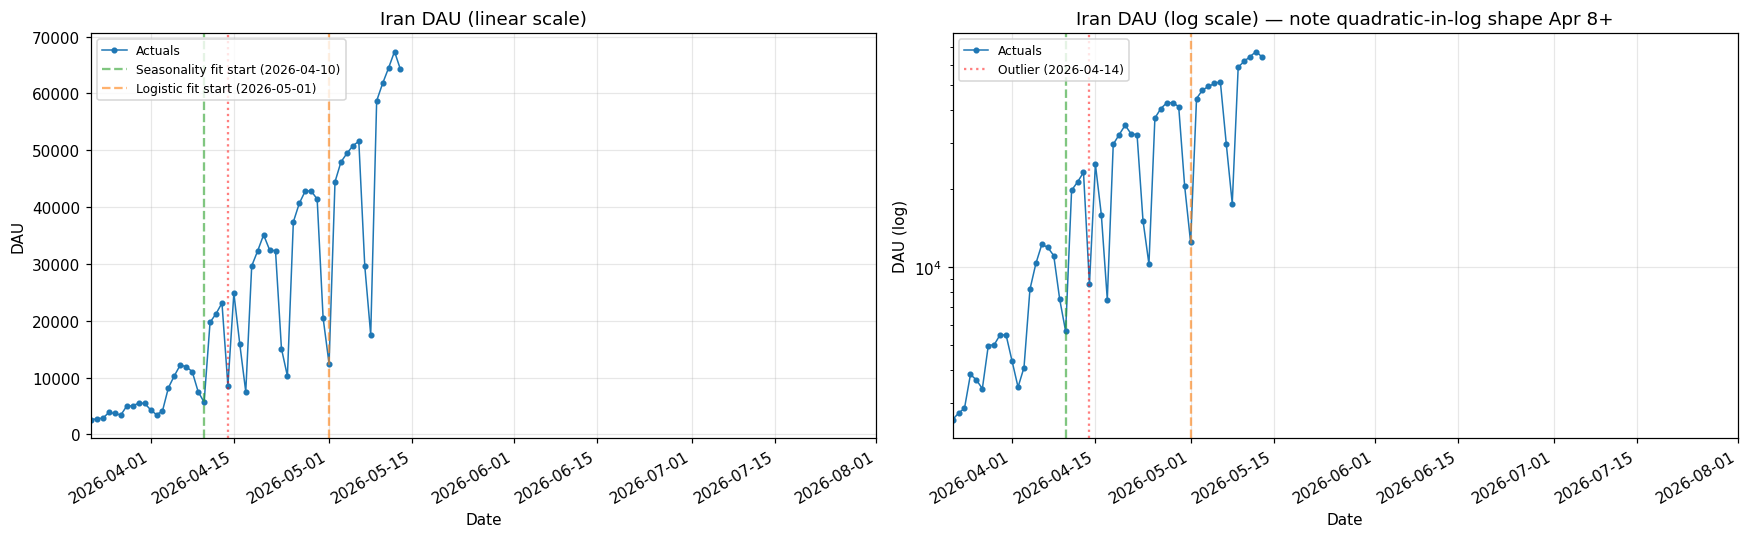

In [58]:
# [raw-plot]
plot_data = raw[(raw.index >= PLOT_START) & (raw.index <= PLOT_END)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(plot_data.index, plot_data['dau'], 'o-', markersize=3, linewidth=1, color='C0', label='Actuals')
ax.axvline(SEASONALITY_FIT_START, color='C2', linestyle='--', alpha=0.6, label=f'Seasonality fit start ({SEASONALITY_FIT_START.date()})')
ax.axvline(LOGISTIC_FIT_START, color='C1', linestyle='--', alpha=0.6, label=f'Logistic fit start ({LOGISTIC_FIT_START.date()})')
for outlier in SEASONALITY_OUTLIERS:
    ax.axvline(outlier, color='red', linestyle=':', alpha=0.5)
ax.set_title('Iran DAU (linear scale)')
ax.set_ylabel('DAU')
ax.set_xlabel('Date')
ax.set_xlim(PLOT_START, PLOT_END)
ax.legend(fontsize=8, loc='upper left')
fig.autofmt_xdate()

ax = axes[1]
ax.semilogy(plot_data.index, plot_data['dau'], 'o-', markersize=3, linewidth=1, color='C0', label='Actuals')
ax.axvline(SEASONALITY_FIT_START, color='C2', linestyle='--', alpha=0.6)
ax.axvline(LOGISTIC_FIT_START, color='C1', linestyle='--', alpha=0.6)
for outlier in SEASONALITY_OUTLIERS:
    ax.axvline(outlier, color='red', linestyle=':', alpha=0.5, label=f'Outlier ({outlier.date()})')
ax.set_title('Iran DAU (log scale) — note quadratic-in-log shape Apr 8+')
ax.set_ylabel('DAU (log)')
ax.set_xlabel('Date')
ax.set_xlim(PLOT_START, PLOT_END)
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

## Step 1: Extract weekly seasonality via log-space OLS

Fit `log(DAU) = β₀ + β₁ t + β₂ t² + Σ α_d · 1[dow=d] + ε` on the seasonality
window, with Monday as the reference day-of-week (α_Mon = 0 by construction).
The quadratic absorbs the supply-driven trend shape; we extract only the `α_d`
as day-of-week effects, exponentiate to multiplicative factors, and normalize
to geometric-mean = 1.

The quadratic trend is **discarded after extraction** — its forecast properties
are meaningless (it grows super-exponentially), but as a local detrend over the
fit window it does its job.

OLS fit (log_dau ~ t + t^2 + C(dow); Monday reference):
  intercept       coef =    9.9639   se = 0.0451
  t               coef =    0.0437   se = 0.0048
  t_sq            coef =   -0.0002   se = 0.0001
  dow_Tue         coef =   -0.0239   se = 0.0465
  dow_Wed         coef =   -0.0713   se = 0.0435
  dow_Thu         coef =   -0.7238   se = 0.0464
  dow_Fri         coef =   -1.3042   se = 0.0436
  dow_Sat         coef =   -0.0611   se = 0.0435
  dow_Sun         coef =   -0.0235   se = 0.0435
  R^2 = 0.9912,  n = 33

Weekly seasonality factors (geomean = 1):
  Mon: 1.371
  Tue: 1.338
  Wed: 1.277
  Thu: 0.665
  Fri: 0.372
  Sat: 1.290
  Sun: 1.339


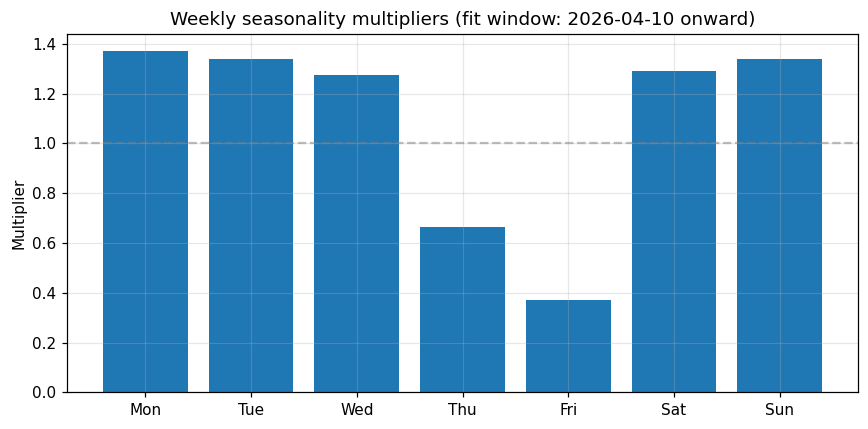

In [59]:
# [seasonality-fit]
season_window = raw[raw.index >= SEASONALITY_FIT_START].copy()
season_window = season_window[~season_window.index.isin(SEASONALITY_OUTLIERS)]
season_window['t'] = (season_window.index - SEASONALITY_FIT_START).days.astype(float)
season_window['dow'] = season_window.index.dayofweek
# Cast dau through astype(float) before np.log to avoid pandas FloatingArray
# (statsmodels won't accept extension-array inputs).
season_window['log_dau'] = np.log(season_window['dau'].astype(float))

# Design matrix: [intercept, t, t^2, dow=1, dow=2, ..., dow=6] (Monday = reference).
# Use to_numpy(dtype=float) everywhere so OLS sees plain ndarrays.
t_vals = season_window['t'].to_numpy(dtype=float)
dow_vals = season_window['dow'].to_numpy(dtype=int)
X = np.column_stack([
    np.ones(len(season_window), dtype=float),
    t_vals,
    t_vals ** 2,
    *[(dow_vals == d).astype(float) for d in range(1, 7)],
])
col_names = ['intercept', 't', 't_sq'] + [f'dow_{DOW_LABELS[d]}' for d in range(1, 7)]
y_log = season_window['log_dau'].to_numpy(dtype=float)

ols_model = sm.OLS(y_log, X).fit()

print('OLS fit (log_dau ~ t + t^2 + C(dow); Monday reference):')
for name, coef, se in zip(col_names, ols_model.params, ols_model.bse):
    print(f'  {name:<14}  coef = {coef:>9.4f}   se = {se:.4f}')
print(f'  R^2 = {ols_model.rsquared:.4f},  n = {ols_model.nobs:.0f}')

# Extract day-of-week log effects (Mon=0 by reference, others from fitted coefs)
dow_log_effects = np.zeros(7)
for i, d in enumerate(range(1, 7)):
    dow_log_effects[d] = ols_model.params[3 + i]

# Convert to multiplicative factors, normalize to geomean = 1
dow_factors_raw = np.exp(dow_log_effects)
weekly_factor = pd.Series(
    dow_factors_raw / np.exp(np.log(dow_factors_raw).mean()),
    index=range(7),
)

print()
print('Weekly seasonality factors (geomean = 1):')
for i, lbl in enumerate(DOW_LABELS):
    print(f'  {lbl}: {weekly_factor[i]:.3f}')

# Quick bar chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(DOW_LABELS, weekly_factor.values, color='C0')
ax.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax.set_title(f'Weekly seasonality multipliers (fit window: {SEASONALITY_FIT_START.date()} onward)')
ax.set_ylabel('Multiplier')
plt.tight_layout()
plt.show()


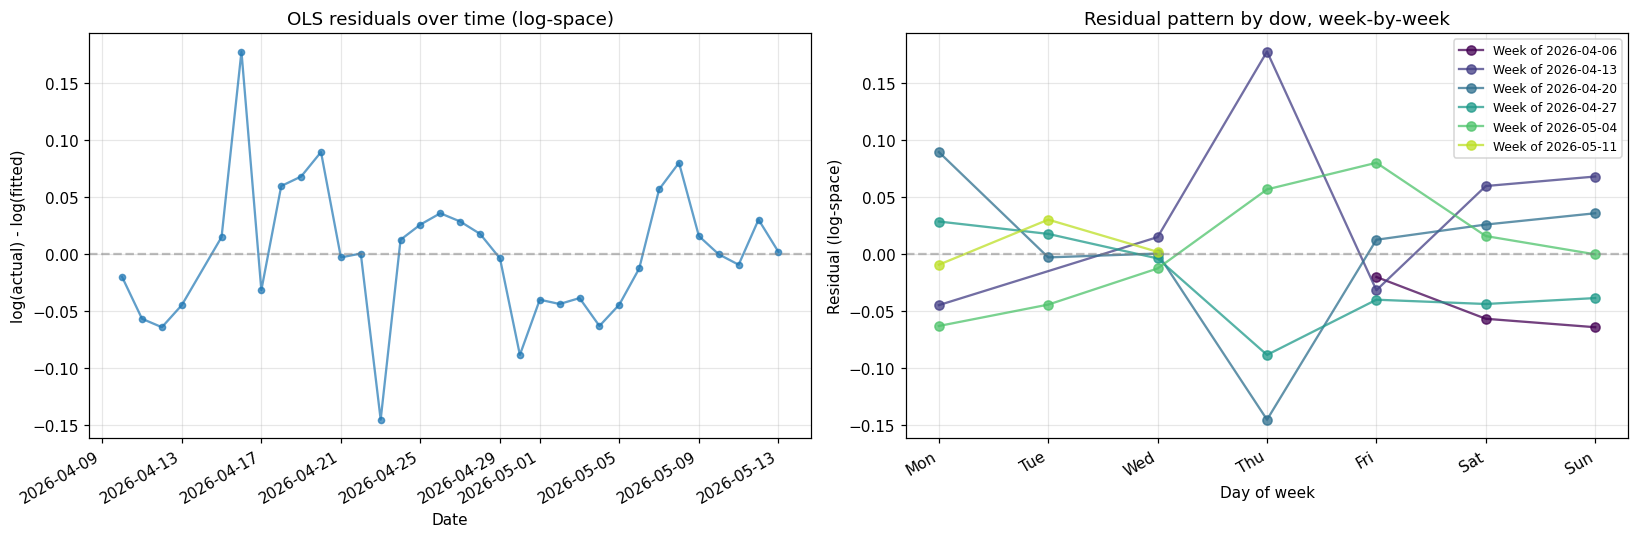

Residual stddev by week:
  Week of 2026-04-06: std = 0.024  (n = 3)
  Week of 2026-04-13: std = 0.081  (n = 6)
  Week of 2026-04-20: std = 0.072  (n = 7)
  Week of 2026-04-27: std = 0.041  (n = 7)
  Week of 2026-05-04: std = 0.051  (n = 7)
  Week of 2026-05-11: std = 0.020  (n = 3)


In [60]:
# [seasonality-diagnostic]
# Check whether the weekly pattern is stable across weeks of the fit window.
# If week-1 residuals look systematically different from week-5 residuals,
# the seasonal factors are picking up regime-shift noise.

season_window['fitted_log'] = ols_model.fittedvalues
season_window['residual_log'] = y_log - season_window['fitted_log']
season_window['week_start'] = season_window.index - pd.to_timedelta(season_window.index.dayofweek, unit='d')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(season_window.index, season_window['residual_log'], 'o-', color='C0', alpha=0.7, markersize=4)
ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax.set_title('OLS residuals over time (log-space)')
ax.set_ylabel('log(actual) - log(fitted)')
ax.set_xlabel('Date')
ax.grid(alpha=0.3)
fig.autofmt_xdate()

ax = axes[1]
weeks_sorted = sorted(season_window['week_start'].unique())
colors = plt.cm.viridis(np.linspace(0, 0.9, len(weeks_sorted)))
for week, color in zip(weeks_sorted, colors):
    wk = season_window[season_window['week_start'] == week].sort_values('dow')
    ax.plot(wk['dow'], wk['residual_log'], 'o-', color=color, alpha=0.75,
            label=f'Week of {pd.Timestamp(week).date()}')
ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax.set_xticks(range(7))
ax.set_xticklabels(DOW_LABELS)
ax.set_title('Residual pattern by dow, week-by-week')
ax.set_ylabel('Residual (log-space)')
ax.set_xlabel('Day of week')
ax.legend(fontsize=8, loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Residual stddev by week:')
for week in weeks_sorted:
    wk = season_window[season_window['week_start'] == week]
    print(f'  Week of {pd.Timestamp(week).date()}: std = {wk["residual_log"].std():.3f}  (n = {len(wk)})')

## Step 2: Cap-pinned logistic fit

Deseasonalize the May 1+ data (divide by weekly factor for each day's dow), then
fit a 2-parameter logistic with `cap` pinned at each scenario value:

$$\text{trend}(t) = \frac{\text{cap}}{1 + \exp(-k(t - t_0))}$$

Only `k` (growth rate) and `t_0` (inflection point) are fit. The cap is
externally supplied based on demographic reasoning. Three scenarios run
simultaneously so we can see how the forecast shifts with different cap
assumptions.

In [61]:
# [logistic-fit]
logistic_window = raw[raw.index >= LOGISTIC_FIT_START].copy()
logistic_window['t_days'] = (logistic_window.index - LOGISTIC_FIT_START).days.astype(float)
logistic_window['dow'] = logistic_window.index.dayofweek
logistic_window['dau_des'] = (logistic_window['dau'].astype(float)
                              / logistic_window['dow'].map(weekly_factor))

MAX_SEASONAL = float(weekly_factor.max())


def make_pinned_logistic(cap_value):
    """Logistic where `cap_value` represents the peak-weekly forecast value.

    The underlying logistic asymptotes at cap_value / max(weekly_factor); after
    multiplying by the seasonal factor at the highest-seasonality dow, the
    forecast peaks at exactly cap_value.
    """
    effective_cap = cap_value / MAX_SEASONAL
    def _f(t, k, t0):
        return effective_cap / (1.0 + np.exp(-k * (t - t0)))
    return _f


scenarios = {}
for cap_value in CAP_SCENARIOS:
    fit_func = make_pinned_logistic(cap_value)
    p0 = [0.1, 7.0]
    bounds = ([0.001, -50.0], [2.0, 300.0])
    params, cov = curve_fit(
        fit_func,
        logistic_window['t_days'].to_numpy(dtype=float),
        logistic_window['dau_des'].to_numpy(dtype=float),
        p0=p0, bounds=bounds, maxfev=10_000,
    )
    perr = np.sqrt(np.diag(cov))
    scenarios[cap_value] = {
        'cap': cap_value,
        'effective_cap': cap_value / MAX_SEASONAL,
        'k': params[0],
        'k_sigma': perr[0],
        't0': params[1],
        't0_sigma': perr[1],
        'inflection_date': LOGISTIC_FIT_START + pd.Timedelta(days=params[1]),
    }

print(f'Cap-pinned logistic fits on {LOGISTIC_FIT_START.date()} onward ({len(logistic_window)} days).')
print(f'Cap convention: cap = peak forecast value (highest-seasonal day at saturation).')
print(f'  max(weekly_factor) = {MAX_SEASONAL:.3f}  -> trend asymptote = cap / {MAX_SEASONAL:.3f}')
print()
print(f'  {"cap":>8}  {"eff_cap":>8}  {"k":>7}  {"k_sigma":>9}  {"doubling":>8}  {"t0":>5}  {"inflection":<11}  shipping?')
print(f'  {"-"*8}  {"-"*8}  {"-"*7}  {"-"*9}  {"-"*8}  {"-"*5}  {"-"*11}  {"-"*9}')
for cap_value, s in scenarios.items():
    flag = 'YES' if cap_value == SHIPPING_CAP else ''
    doubling = np.log(2) / s['k']
    print(f'  {cap_value:>8,}  {s["effective_cap"]:>8,.0f}  {s["k"]:>7.4f}  {s["k_sigma"]:>9.4f}  '
          f'{doubling:>7.1f}d  {s["t0"]:>5.1f}  {s["inflection_date"].date()}  {flag}')


Cap-pinned logistic fits on 2026-05-01 onward (13 days).
Cap convention: cap = peak forecast value (highest-seasonal day at saturation).
  max(weekly_factor) = 1.371  -> trend asymptote = cap / 1.371

       cap   eff_cap        k    k_sigma  doubling     t0  inflection   shipping?
  --------  --------  -------  ---------  --------  -----  -----------  ---------
   100,000    72,949   0.0874     0.0064      7.9d    2.3  2026-05-03  
   150,000   109,424   0.0589     0.0045     11.8d   14.0  2026-05-14  YES
   200,000   145,899   0.0507     0.0040     13.7d   23.9  2026-05-24  


## Step 3: Final forecast

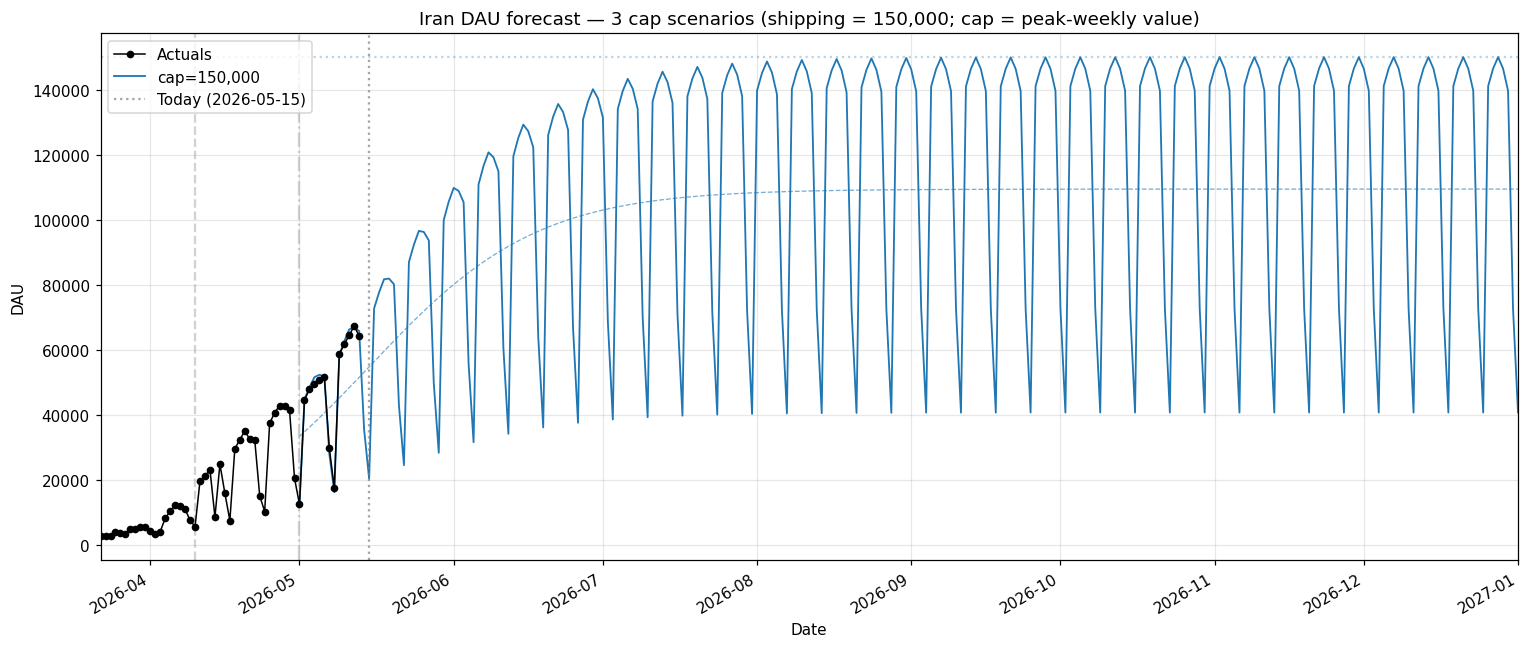

In [71]:
# [forecast-plot]
future_dates = pd.date_range(start=LOGISTIC_FIT_START, end=FORECAST_END, freq='D')
t_future = (future_dates - LOGISTIC_FIT_START).days.astype(float)
seasonal_future = np.array([weekly_factor[d] for d in future_dates.dayofweek])

forecasts = {}
for cap_value, s in scenarios.items():
    trend_future = make_pinned_logistic(cap_value)(t_future, s['k'], s['t0'])
    forecasts[cap_value] = pd.DataFrame(
        {'trend': trend_future, 'forecast': trend_future * seasonal_future},
        index=future_dates,
    )

plot_actuals = raw[(raw.index >= PLOT_START) & (raw.index <= FORECAST_PLOT_END)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_actuals.index, plot_actuals['dau'], 'o-', markersize=4, linewidth=1,
        color='black', label='Actuals', zorder=10)

# Sort scenarios so shipping is plotted last (on top)
sorted_caps = sorted(CAP_SCENARIOS, key=lambda c: c == SHIPPING_CAP)
cap_colors = {100_000: 'tab:red', 150_000: 'tab:blue', 200_000: 'tab:green'}
for cap_value in sorted_caps:
    if cap_value != 150_000:
        continue
    fc = forecasts[cap_value]
    color = cap_colors.get(cap_value, 'tab:red')
    mask = (fc.index >= PLOT_START) & (fc.index <= FORECAST_PLOT_END)
    is_shipping = cap_value == SHIPPING_CAP
    lw = 1.2 #2.2 if is_shipping else 1.2
    alpha = 1.0 if is_shipping else 0.55
    label = f'cap={cap_value:,}'# + (' (SHIPPING)' if is_shipping else '')
    ax.plot(fc.index[mask], fc.loc[mask, 'forecast'], color=color, linewidth=lw, alpha=alpha, label=label)
    ax.plot(fc.index[mask], fc.loc[mask, 'trend'], color=color, linewidth=lw * 0.7,
            linestyle='--', alpha=alpha * 0.6)
    # Cap line at peak (= forecast at saturation on highest-seasonal day)
    ax.axhline(cap_value, color=color, linestyle=':', alpha=0.3)

ax.axvline(SEASONALITY_FIT_START, color='grey', linestyle='--', alpha=0.35)
ax.axvline(LOGISTIC_FIT_START, color='grey', linestyle='-.', alpha=0.35)
ax.axvline(TODAY, color='grey', linestyle=':', alpha=0.7, label=f'Today ({TODAY.date()})')
ax.set_title(f'Iran DAU forecast — 3 cap scenarios (shipping = {SHIPPING_CAP:,}; cap = peak-weekly value)')
ax.set_ylabel('DAU')
ax.set_xlabel('Date')
ax.set_xlim(PLOT_START, FORECAST_PLOT_END)
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Interactive plot (zoomable)

In [63]:
# [interactive-plot]
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=plot_actuals.index, y=plot_actuals['dau'],
    mode='markers+lines', marker=dict(size=5), name='Actuals',
    line=dict(color='black', width=1.2),
))

plotly_colors = {100_000: 'royalblue', 150_000: 'darkorange', 200_000: 'mediumseagreen'}
for cap_value in sorted_caps:
    fc = forecasts[cap_value]
    mask = (fc.index >= PLOT_START) & (fc.index <= FORECAST_PLOT_END)
    is_shipping = cap_value == SHIPPING_CAP
    fig.add_trace(go.Scatter(
        x=fc.index[mask], y=fc.loc[mask, 'forecast'],
        mode='lines', name=f'cap={cap_value:,}' + (' (SHIPPING)' if is_shipping else ''),
        line=dict(color=plotly_colors.get(cap_value, 'firebrick'),
                  width=2.6 if is_shipping else 1.4),
        opacity=1.0 if is_shipping else 0.6,
    ))

# Today line + annotation (avoid add_vline; broken with date x in plotly 6.x)
_today_iso = TODAY.strftime('%Y-%m-%d')
fig.add_shape(
    type='line', x0=_today_iso, x1=_today_iso, y0=0, y1=1, yref='paper',
    line=dict(color='grey', dash='dot'),
)
fig.add_annotation(
    x=_today_iso, y=1.02, yref='paper', text='Today',
    showarrow=False, font=dict(color='grey'),
)

fig.update_layout(
    title=f'Iran DAU forecast — interactive (shipping cap = {SHIPPING_CAP:,}; cap = peak-weekly)',
    xaxis_title='Date', yaxis_title='DAU',
    hovermode='x unified',
    width=1100, height=600,
    xaxis=dict(range=[PLOT_START.strftime('%Y-%m-%d'), FORECAST_PLOT_END.strftime('%Y-%m-%d')]),
)
fig.show()


## Text summary (paste back to iterate)

In [64]:
# [text-summary]
ship_s = scenarios[SHIPPING_CAP]
ship_fc = forecasts[SHIPPING_CAP]

# Weekly trajectory for shipping forecast
combined = ship_fc[['forecast', 'trend']].copy()
combined['actual'] = raw['dau']
combined = combined[combined.index <= FORECAST_PLOT_END]
combined['week_start'] = combined.index - pd.to_timedelta(combined.index.dayofweek, unit='d')

weekly = combined.groupby('week_start').agg(
    actual=('actual', 'mean'),
    forecast=('forecast', 'mean'),
    trend=('trend', 'mean'),
).round(0)
weekly = weekly[weekly.index >= (PLOT_START - pd.Timedelta(days=7))]

BAR_WIDTH = 32
lines = []
lines.append('=' * 82)
lines.append(f'Iran Partial-Recovery Forecast (v2) — SHIPPING (cap = {SHIPPING_CAP:,})')
lines.append('=' * 82)
lines.append(f'Seasonality fit: {SEASONALITY_FIT_START.date()} -> {raw.index.max().date()} '
             f'(excluding {[t.date().isoformat() for t in SEASONALITY_OUTLIERS]})')
lines.append(f'Logistic fit:    {LOGISTIC_FIT_START.date()} -> {raw.index.max().date()} '
             f'({(raw.index.max() - LOGISTIC_FIT_START).days + 1} days, cap pinned)')
lines.append(f'Cap convention:  cap = peak weekly forecast at saturation')
lines.append(f'                 (logistic asymptote = cap / max(weekly_factor) = cap / {weekly_factor.max():.3f})')
lines.append('')
lines.append('Shipping forecast parameters:')
lines.append(f'  cap            = {SHIPPING_CAP:>10,.0f}   (PEAK; PINNED)')
lines.append(f'  trend asymptote= {ship_s["effective_cap"]:>10,.0f}   (= cap / {weekly_factor.max():.3f})')
lines.append(f'  k              = {ship_s["k"]:>10.4f}   (1-sigma +/- {ship_s["k_sigma"]:.4f})')
lines.append(f'  inflection     = {ship_s["inflection_date"].date()}   '
             f'(t0 = {ship_s["t0"]:.1f}d after {LOGISTIC_FIT_START.date()})')
lines.append(f'  doubling       = {np.log(2)/ship_s["k"]:.1f} days near inflection')
lines.append('')
lines.append('Weekly seasonality factors (geomean = 1):')
lines.append('  ' + '   '.join(f'{DOW_LABELS[i]}={weekly_factor[i]:.2f}' for i in range(7)))
lines.append('')
lines.append('Sensitivity (all caps; DAU values at end of forecast plot):')
end_label = FORECAST_PLOT_END.strftime('%Y-%m-%d')
lines.append(f'  {"cap":>8}  {"k":>7}  {"infl_date":<11}  {"DAU @ "+end_label:>17}  {"pct of cap":>11}')
for cap_value in CAP_SCENARIOS:
    s = scenarios[cap_value]
    fc = forecasts[cap_value]
    end_val = fc.loc[fc.index <= FORECAST_PLOT_END, 'forecast'].iloc[-1]
    flag = '  << SHIPPING' if cap_value == SHIPPING_CAP else ''
    lines.append(f'  {cap_value:>8,}  {s["k"]:>7.4f}  {s["inflection_date"].date()}  '
                 f'{end_val:>17,.0f}  {100*end_val/cap_value:>10.1f}%{flag}')
lines.append('')
lines.append(f'Weekly trajectory for SHIPPING forecast (bar = pct of cap {SHIPPING_CAP:,}):')
lines.append(f'  {"week-start":<12}  {"actual":>9}  {"forecast":>9}  {"pct-cap":>8}  bar')
lines.append(f'  {"-"*12}  {"-"*9}  {"-"*9}  {"-"*8}  {"-"*BAR_WIDTH}')
for ws, row in weekly.iterrows():
    val = row['actual'] if not pd.isna(row['actual']) else row['forecast']
    bar_n = max(0, min(BAR_WIDTH, int(round(BAR_WIDTH * val / SHIPPING_CAP))))
    bar = '#' * bar_n + '.' * (BAR_WIDTH - bar_n)
    a_str = f'{row["actual"]:,.0f}' if not pd.isna(row['actual']) else '-'
    f_str = f'{row["forecast"]:,.0f}' if not pd.isna(row['forecast']) else '-'
    marker = '(a)' if not pd.isna(row['actual']) else '(f)'
    lines.append(f'  {ws.strftime("%Y-%m-%d"):<12}  {a_str:>9}  {f_str:>9}  '
                 f'{100*val/SHIPPING_CAP:>7.1f}%  {bar} {marker}')
lines.append('')
lines.append('Legend: (a) = actuals (may be partial for current week); (f) = forecast only')

print('\n'.join(lines))


Iran Partial-Recovery Forecast (v2) — SHIPPING (cap = 150,000)
Seasonality fit: 2026-04-10 -> 2026-05-13 (excluding ['2026-04-14'])
Logistic fit:    2026-05-01 -> 2026-05-13 (13 days, cap pinned)
Cap convention:  cap = peak weekly forecast at saturation
                 (logistic asymptote = cap / max(weekly_factor) = cap / 1.371)

Shipping forecast parameters:
  cap            =    150,000   (PEAK; PINNED)
  trend asymptote=    109,424   (= cap / 1.371)
  k              =     0.0589   (1-sigma +/- 0.0045)
  inflection     = 2026-05-14   (t0 = 14.0d after 2026-05-01)
  doubling       = 11.8 days near inflection

Weekly seasonality factors (geomean = 1):
  Mon=1.37   Tue=1.34   Wed=1.28   Thu=0.66   Fri=0.37   Sat=1.29   Sun=1.34

Sensitivity (all caps; DAU values at end of forecast plot):
       cap        k  infl_date     DAU @ 2027-01-01   pct of cap
   100,000   0.0874  2026-05-03             27,138        27.1%
   150,000   0.0589  2026-05-14             40,707        27.1%  << SHI

## Sensitivity: logistic-fit-start sweep

Sweep the logistic fit-start date by ±7 days around May 1, with cap pinned at
`SHIPPING_CAP`. If `k` and `t₀` are stable across this window, the choice of
fit-start isn't load-bearing. If they vary wildly, the May-1 anchor is fragile.

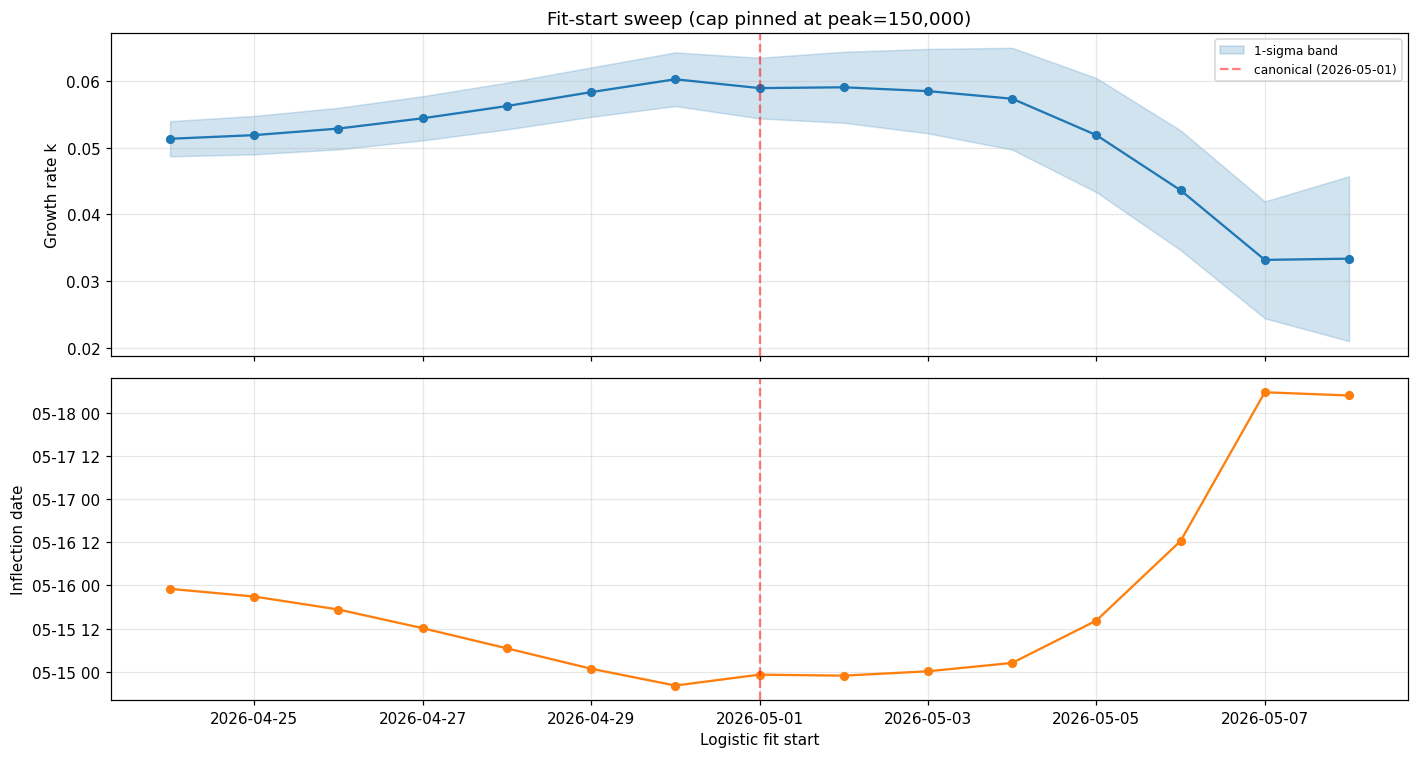

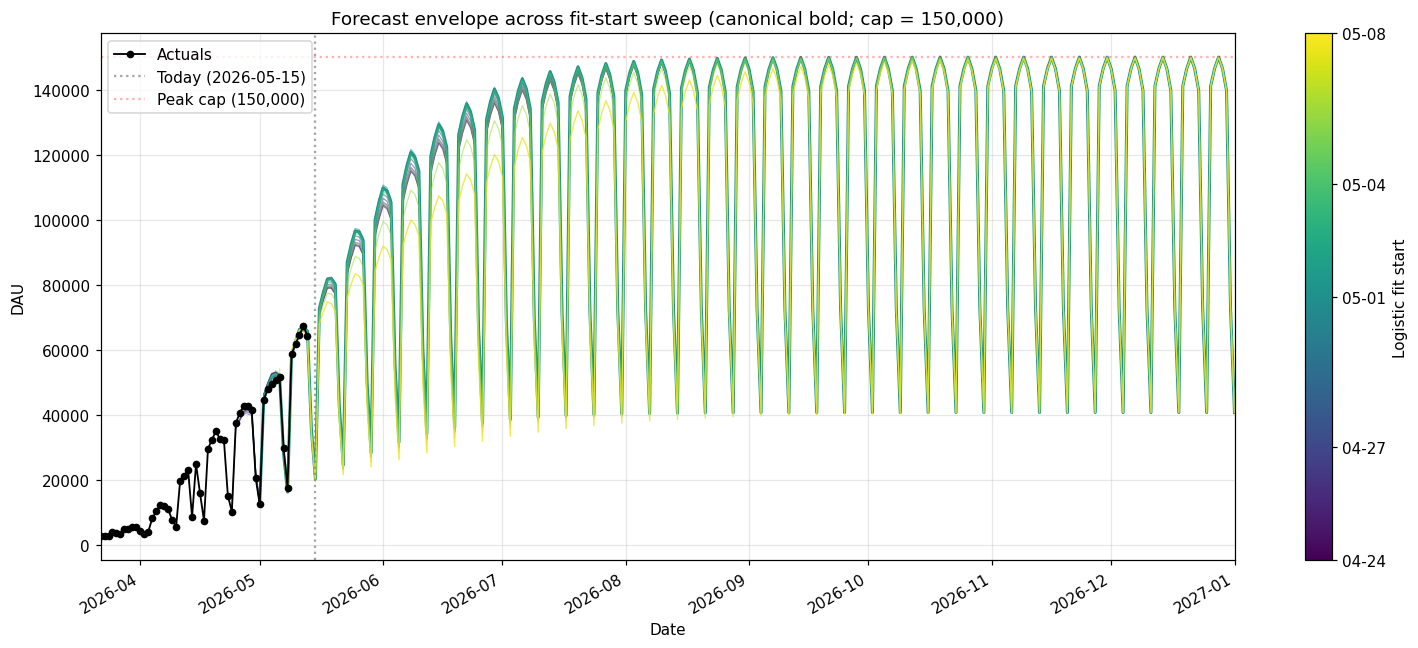

In [65]:
# [fit-start-sweep]
sweep_starts = pd.date_range(
    LOGISTIC_FIT_START - pd.Timedelta(days=LOGISTIC_SWEEP_HALFWIDTH_DAYS),
    LOGISTIC_FIT_START + pd.Timedelta(days=LOGISTIC_SWEEP_HALFWIDTH_DAYS),
    freq='D',
)

sweep_rows = []
sweep_forecasts = {}
fit_func_sweep = make_pinned_logistic(SHIPPING_CAP)  # cap convention applied here

for s_start in sweep_starts:
    fw = raw[raw.index >= s_start].copy()
    if len(fw) < 5:
        continue
    fw['t_days'] = (fw.index - s_start).days.astype(float)
    fw['dow'] = fw.index.dayofweek
    fw['dau_des'] = fw['dau'].astype(float) / fw['dow'].map(weekly_factor)

    try:
        params, cov = curve_fit(
            fit_func_sweep,
            fw['t_days'].to_numpy(dtype=float),
            fw['dau_des'].to_numpy(dtype=float),
            p0=[0.1, 7.0], bounds=([0.001, -50.0], [2.0, 300.0]),
            maxfev=10_000,
        )
        perr = np.sqrt(np.diag(cov))

        future_i = pd.date_range(start=s_start, end=FORECAST_END, freq='D')
        t_fi = (future_i - s_start).days.astype(float)
        trend_i = fit_func_sweep(t_fi, *params)
        seasonal_i = np.array([weekly_factor[d] for d in future_i.dayofweek])
        sweep_forecasts[s_start] = pd.Series(trend_i * seasonal_i, index=future_i)

        sweep_rows.append({
            'fit_start': s_start,
            'n_days_obs': int((raw.index.max() - s_start).days + 1),
            'k': params[0],
            'k_sigma': perr[0],
            't0': params[1],
            'inflection_date': s_start + pd.Timedelta(days=params[1]),
        })
    except (RuntimeError, ValueError) as e:
        sweep_rows.append({
            'fit_start': s_start,
            'n_days_obs': int((raw.index.max() - s_start).days + 1),
            'k': np.nan, 'k_sigma': np.nan, 't0': np.nan,
            'inflection_date': pd.NaT,
        })
        print(f'Fit failed for start={s_start.date()}: {e}')

sweep_df = pd.DataFrame(sweep_rows).set_index('fit_start')

# ---- Parameter trajectories ----
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.fill_between(
    sweep_df.index,
    sweep_df['k'] - sweep_df['k_sigma'],
    sweep_df['k'] + sweep_df['k_sigma'],
    alpha=0.2, color='C0', label='1-sigma band',
)
ax.plot(sweep_df.index, sweep_df['k'], 'o-', color='C0', markersize=5)
ax.axvline(LOGISTIC_FIT_START, color='red', linestyle='--', alpha=0.5,
           label=f'canonical ({LOGISTIC_FIT_START.date()})')
ax.set_ylabel('Growth rate k')
ax.set_title(f'Fit-start sweep (cap pinned at peak={SHIPPING_CAP:,})')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(sweep_df.index, sweep_df['inflection_date'], 'o-', color='C1', markersize=5)
ax.axvline(LOGISTIC_FIT_START, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('Inflection date')
ax.set_xlabel('Logistic fit start')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Forecast envelope ----
fig, ax = plt.subplots(figsize=(14, 6))
plot_actuals_sw = raw[(raw.index >= PLOT_START) & (raw.index <= FORECAST_PLOT_END)]
ax.plot(plot_actuals_sw.index, plot_actuals_sw['dau'], 'o-', markersize=4, color='black',
        label='Actuals', zorder=5, linewidth=1.2)

starts_list = sorted(sweep_forecasts.keys())
cmap = plt.cm.viridis
for i, start in enumerate(starts_list):
    fc = sweep_forecasts[start]
    color = cmap(i / max(1, len(starts_list) - 1))
    mask = (fc.index >= PLOT_START) & (fc.index <= FORECAST_PLOT_END)
    is_canonical = (start == LOGISTIC_FIT_START)
    ax.plot(fc.index[mask], fc[mask], color=color, linewidth=2.0 if is_canonical else 0.8,
            alpha=1.0 if is_canonical else 0.55)

norm = plt.Normalize(vmin=0, vmax=max(1, len(starts_list) - 1))
sm_mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm_mappable.set_array([])
tick_idx = np.linspace(0, len(starts_list) - 1, 5).astype(int)
cbar = fig.colorbar(sm_mappable, ax=ax, ticks=tick_idx)
cbar.ax.set_yticklabels([starts_list[i].strftime('%m-%d') for i in tick_idx])
cbar.set_label('Logistic fit start')

ax.axvline(TODAY, color='grey', linestyle=':', alpha=0.7, label=f'Today ({TODAY.date()})')
ax.axhline(SHIPPING_CAP, color='red', linestyle=':', alpha=0.3, label=f'Peak cap ({SHIPPING_CAP:,})')
ax.set_title(f'Forecast envelope across fit-start sweep (canonical bold; cap = {SHIPPING_CAP:,})')
ax.set_ylabel('DAU')
ax.set_xlabel('Date')
ax.set_xlim(PLOT_START, FORECAST_PLOT_END)
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [66]:
# [sweep-text]
lines = []
lines.append('=' * 82)
lines.append(f'Logistic fit-start sweep  (cap pinned at {SHIPPING_CAP:,})')
lines.append('=' * 82)
lines.append(f'Sweep range: {sweep_df.index[0].date()} -> {sweep_df.index[-1].date()}  '
             f'({len(sweep_df)} fits, canonical = {LOGISTIC_FIT_START.date()})')
lines.append('')

valid = sweep_df.dropna(subset=['k'])
if len(valid) > 0:
    lines.append('k statistics:')
    lines.append(f'  median = {valid["k"].median():.4f}')
    lines.append(f'  IQR    = {valid["k"].quantile(0.25):.4f} - {valid["k"].quantile(0.75):.4f}')
    lines.append(f'  range  = {valid["k"].min():.4f} - {valid["k"].max():.4f}')
    lines.append('')
    lines.append('Inflection date statistics:')
    lines.append(f'  median = {valid["inflection_date"].median().date()}')
    lines.append(f'  IQR    = {valid["inflection_date"].quantile(0.25).date()} '
                 f'to {valid["inflection_date"].quantile(0.75).date()}')
    lines.append('')

lines.append('Per-day fits:')
lines.append(f'  {"fit_start":<11}  {"days":>4}  {"k":>7}  {"k_sigma":>9}  {"infl_date":<11}  {"flag"}')
lines.append(f'  {"-"*11}  {"-"*4}  {"-"*7}  {"-"*9}  {"-"*11}  {"-"*9}')
for fit_start, row in sweep_df.iterrows():
    canonical = fit_start == LOGISTIC_FIT_START
    flag = ' canonical' if canonical else ''
    if pd.isna(row['k']):
        lines.append(f'  {fit_start.strftime("%Y-%m-%d"):<11}  {row["n_days_obs"]:>4}  '
                     f'{"-":>7}  {"-":>9}  {"-":<11}  FAIL')
    else:
        infl_str = row['inflection_date'].strftime('%Y-%m-%d')
        lines.append(f'  {fit_start.strftime("%Y-%m-%d"):<11}  {row["n_days_obs"]:>4}  '
                     f'{row["k"]:>7.4f}  {row["k_sigma"]:>9.4f}  {infl_str:<11} {flag}')

print('\n'.join(lines))

Logistic fit-start sweep  (cap pinned at 150,000)
Sweep range: 2026-04-24 -> 2026-05-08  (15 fits, canonical = 2026-05-01)

k statistics:
  median = 0.0544
  IQR    = 0.0516 - 0.0584
  range  = 0.0332 - 0.0603

Inflection date statistics:
  median = 2026-05-15
  IQR    = 2026-05-15 to 2026-05-15

Per-day fits:
  fit_start    days        k    k_sigma  infl_date    flag
  -----------  ----  -------  ---------  -----------  ---------
  2026-04-24     20   0.0513     0.0026  2026-05-15  
  2026-04-25     19   0.0519     0.0029  2026-05-15  
  2026-04-26     18   0.0529     0.0031  2026-05-15  
  2026-04-27     17   0.0544     0.0033  2026-05-15  
  2026-04-28     16   0.0563     0.0035  2026-05-15  
  2026-04-29     15   0.0583     0.0037  2026-05-15  
  2026-04-30     14   0.0603     0.0040  2026-05-14  
  2026-05-01     13   0.0589     0.0045  2026-05-14   canonical
  2026-05-02     12   0.0591     0.0053  2026-05-14  
  2026-05-03     11   0.0585     0.0063  2026-05-15  
  2026-05-04   

## Reading the result

1. **Seasonality residuals** (diagnostic plot above): should be small (|residual_log|
   typically < 0.15 = ±15% in linear space) and *similar in pattern* across weeks.
   Systematic week-to-week drift means the seasonal factors are picking up
   non-seasonal regime shifts.

2. **Cap-pinned k values**: should be in the range 0.05–0.15 (doubling times of
   5–14 days). Much faster than that and we're seeing pure exponential, not
   logistic — the cap is too high. Much slower and the cap may be too low.

3. **Fit-start sweep stability**: `k` and inflection date should be roughly
   constant across the ±7d sweep. Visible trends in either direction signal that
   the fit is anchored to specific data points rather than the underlying
   trajectory shape.

4. **Shipping vs sensitivity scenarios**: the gap between 100k and 200k forecasts
   at Aug 1 tells you how much the cap choice matters for the near-term picture.
   The further out you go, the larger the gap becomes.